In [30]:
from google.colab import files
file = files.upload()

Saving bank_marketing_full.csv to bank_marketing_full (2).csv


Libraries importring

In [32]:
import os
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['PYTHONHASHSEED'] = '42'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc

from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from collections import Counter


In [33]:
data = pd.read_csv("bank_marketing_full.csv")
df = pd.DataFrame(data)
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [34]:
df = data.copy()

total_nulls = df.isnull().sum().sum()
print(f"Total Nulls: {total_nulls}") # no nulls

data_shape = df.shape
print(f"Data Shape: {data_shape}")

X = df.iloc[:, :len(df.columns)-1]
y = df.iloc[:, -1].values
print(f"The feasures:\n{X}")
print(f"The target: {y}")

df['y'].value_counts() # imbalanced data

Total Nulls: 0
Data Shape: (41188, 21)
The feasures:
       age          job  marital            education  default housing loan  \
0       56    housemaid  married             basic.4y       no      no   no   
1       57     services  married          high.school  unknown      no   no   
2       37     services  married          high.school       no     yes   no   
3       40       admin.  married             basic.6y       no      no   no   
4       56     services  married          high.school       no      no  yes   
...    ...          ...      ...                  ...      ...     ...  ...   
41183   73      retired  married  professional.course       no     yes   no   
41184   46  blue-collar  married  professional.course       no      no   no   
41185   56      retired  married    university.degree       no     yes   no   
41186   44   technician  married  professional.course       no      no   no   
41187   74      retired  married  professional.course       no     yes   no   

,count
y,
no,36548
yes,4640


Showing the unknown values

In [35]:
unknown_report = []

for col in df.columns:
    count = (df[col] == 'unknown').sum()
    if count > 0:
        percentage = (count / len(df)) * 100
        unknown_report.append({
            'Column': col,
            'Unknown Count': count,
            'Percentage': f"{percentage:.2f}%"
        })

if unknown_report:
    report_df = pd.DataFrame(unknown_report)
    print(f"Unknown Values Report:\n{report_df}")
else:
    print("No 'unknown' values ​​were found in the data.")


Unknown Values Report:
      Column  Unknown Count Percentage
0        job            330      0.80%
1    marital             80      0.19%
2  education           1731      4.20%
3    default           8597     20.87%
4    housing            990      2.40%
5       loan            990      2.40%


Compensating for null values

In [36]:
# first method, compensating for columns related to each other
# filling the "Unknown Education" based on the job

edu_mode_per_job = df[df['education'] != 'unknown'].groupby('job')['education'].agg(lambda x: x.mode()[0]).to_dict()
df.loc[df['education'] == 'unknown', 'education'] = df.loc[df['education'] == 'unknown', 'job'].map(edu_mode_per_job)

# filling the 'uknown job' based on the job
job_mode_per_edu = df[df['job'] != 'unknown'].groupby('education')['job'].agg(lambda x: x.mode()[0]).to_dict()
df.loc[df['job'] == 'unknown', 'job'] = df.loc[df['job'] == 'unknown', 'education'].map(job_mode_per_edu)

# filling the 'uknown marital' based on the age
df['age_group'] = pd.cut(df['age'], bins=[0, 30, 60, 100], labels=['young', 'middle', 'old'])
marital_mode_per_age = df[df['marital'] != 'unknown'].groupby('age_group')['marital'].agg(lambda x: x.mode()[0]).to_dict()
df.loc[df['marital'] == 'unknown', 'marital'] = df.loc[df['marital'] == 'unknown', 'age_group'].map(marital_mode_per_age)
df.drop('age_group', axis=1, inplace=True)

# second one, using the mode (because their percentage is small)
for col in ['housing', 'loan']:
    mode_val = df[df[col] != 'unknown'][col].mode()[0]
    df[col] = df[col].replace('unknown', mode_val)

# last one, filling any remaining gaps in job, marital, education with the mode
for col in ['job', 'marital', 'education']:
    mode_val = df[df[col] != 'unknown'][col].mode()[0]
    df[col] = df[col].replace('unknown', mode_val)

print(f"Unkown values:\n{df[['job', 'marital', 'education', 'housing', 'loan', 'default']].apply(lambda x: (x=='unknown').sum())}")

Unkown values:
job             0
marital         0
education       0
housing         0
loan            0
default      8597
dtype: int64


/tmp/ipykernel_9311/1402998909.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  marital_mode_per_age = df[df['marital'] != 'unknown'].groupby('age_group')['marital'].agg(lambda x: x.mode()[0]).to_dict()


Encoding the columns

In [37]:
# target col
le = LabelEncoder()
df['y'] = le.fit_transform(df['y'])

# features cols using (get_dummies)
df_encoded = pd.get_dummies(df, drop_first=True)

# showing the newiest shape
print(f"The original shape: {df.shape}")
print(f"The shape after making encoding: {df_encoded.shape}")
print("\nThe new cols:")
print(df_encoded.columns.tolist())

print("Target Value Values Count(y):")
print(df_encoded['y'].value_counts())

The original shape: (41188, 21)
The shape after making encoding: (41188, 49)

The new cols:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'marital_married', 'marital_single', 'education_basic.6y', 'education_basic.9y', 'education_high.school', 'education_illiterate', 'education_professional.course', 'education_university.degree', 'default_unknown', 'default_yes', 'housing_yes', 'loan_yes', 'contact_telephone', 'month_aug', 'month_dec', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue', 'day_of_week_wed', 'poutcome_nonexistent', 'poutcome_success']
Target Value Values Count(y):
y
0    36548
1     4640
Name: count, dtype: int64


In [38]:
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

Split The data

In [39]:
# Separating bet x and y
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Doing Scalling

In [40]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Using SMOTE

In [41]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)
print(f"Target Value Values Count after SMOTE: {Counter(y_train_res)}")

Target Value Values Count after SMOTE: Counter({0: 29238, 1: 29238})


Bulling the Model

In [45]:
def build_model(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        # Expanding
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.4),

        # Contracting
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        # Output
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall'),
                 keras.metrics.AUC(name='auc')]
    )
    return model

In [46]:
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    mode='min'
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

Train the Model

In [47]:
model = build_model(input_dim=X_train_res.shape[1])
model.summary()

history = model.fit(
    X_train_res, y_train_res,
    validation_split=0.2,
    epochs=50,
    batch_size=512,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 88,257 (344.75 KB)

 Trainable params: 86,977 (339.75 KB)

 Non-trainable params: 1,280 (5.00 KB)

Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.7409 - auc: 0.8028 - loss: 0.5576 - precision: 0.6551 - recall: 0.6524 - val_accuracy: 0.7125 - val_auc: 0.0000e+00 - val_loss: 0.5395 - val_precision: 1.0000 - val_recall: 0.7125 - learning_rate: 0.0010
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.8363 - auc: 0.9070 - loss: 0.3842 - precision: 0.7668 - recall: 0.8096 - val_accuracy: 0.8974 - val_auc: 0.0000e+00 - val_loss: 0.3265 - val_precision: 1.0000 - val_recall: 0.8974 - learning_rate: 0.0010
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8537 - auc: 0.9202 - loss: 0.3458 - precision: 0.7783 - recall: 0.8529 - val_accuracy: 0.9305 - val_auc: 0.0000e+00 - val_loss: 0.2642 - val_precision: 1.0000 - val_recall: 0.9305 - learning_rate: 0.0010
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8666 - auc: 0.9293 - loss: 0.3186 - precision: 0.7891 - recall: 0.8793 - val_accuracy: 0.9321 - val_auc: 0.0000e+00 - val_loss: 

In [48]:
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.6).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("ROC-AUC Score:")
print(f"AUC: {roc_auc_score(y_test, y_pred_prob):.4f}")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.89      0.93      7310
           1       0.50      0.88      0.64       928

    accuracy                           0.89      8238
   macro avg       0.74      0.88      0.78      8238
weighted avg       0.93      0.89      0.90      8238

ROC-AUC Score:
AUC: 0.9473
Confusion Matrix:
[[6490  820]
 [ 112  816]]


ROC Curve & Confusion Matrix

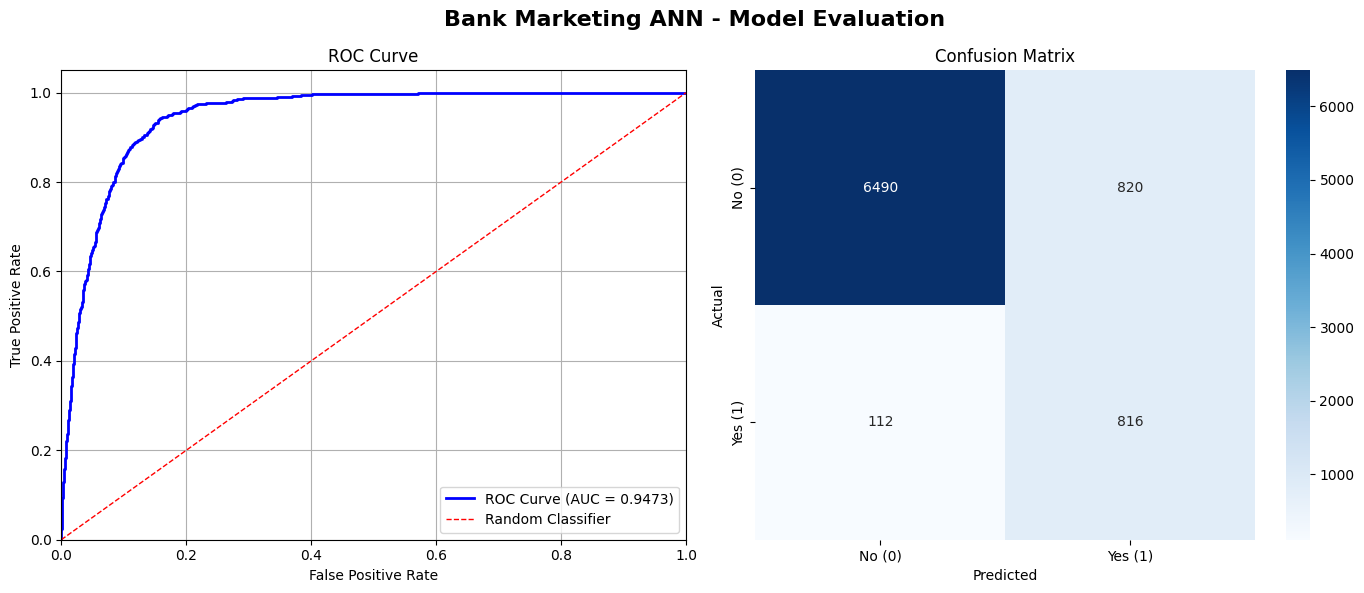

In [49]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Bank Marketing ANN - Model Evaluation', fontsize=16, fontweight='bold')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

ax1.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--', label='Random Classifier')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve')
ax1.legend(loc='lower right')
ax1.grid(True)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=['No (0)', 'Yes (1)'],
            yticklabels=['No (0)', 'Yes (1)'])
ax2.set_title('Confusion Matrix')
ax2.set_ylabel('Actual')
ax2.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

Saving the Model

In [28]:
model.save('bank_marketing_best_model.keras')
print("Model saved")

Model saved
